<div align="center">

# Hierarchical Black Hole Merger Reconstruction
### Start-to-Finish Pipeline: From Merger Trees to Genealogy Recovery

---

*This notebook presents a complete, modular pipeline for simulating and reconstructing hierarchical binary black hole (BBH) merger chains. Each section is self-contained and can be run independently, provided the outputs of upstream sections are available.*

</div>

---

## Pipeline Overview

The notebook is organized into four main stages:

| Stage | Description |
|-------|-------------|
| **I — Merger Tree Generation** | Simulate populations of hierarchical BBH mergers across multiple generations using mixed-generation pairing and exponential generation weights |
| **II — GW Detection & Parameter Estimation** | Inject simulated signals into detector networks (e.g., ET, CE) and recover posteriors via Fisher matrix estimation with GWFish |
| **III — Genealogy Reconstruction** | Apply nested sampling (dynesty) and the `ancestral` package to infer progenitor parameters and reconstruct the merger hierarchy |
| **IV — Accuracy & Likelihood Analysis** | Cross-examine recovered genealogies against ground truth: assess parameter recovery, compute Bayes factors, and evaluate reconstruction fidelity |

---


## Stage I — Merger Tree Generation

In [1]:
#Packages Block
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import sys
sys.path.append("/home/santiago.berumen/branches/Packages")
import lal
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm
import functions2
import bilby, time
import seaborn as sns
import pandas as pd
from pprint import pprint
import os
import corner
import json
import h5py
from astropy.cosmology import Planck18
import GWFish.modules as gw
from GWFish.modules.priors import *
import precession
import ancestral
import importlib
import detection

/home/santiago.berumen/.conda/envs/hierarchical-mergers/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Randomly sample priors for the first gen BHs that will serve as our initial population:

# ---------------------------
# Priors
# ---------------------------
priors = bilby.core.prior.PriorDict()
priors['mass_1'] = bilby.core.prior.analytical.PowerLaw(minimum=5, maximum=50, alpha=-2.3,
                                                        name='mass_1')
priors['a_1'] = bilby.core.prior.Uniform(name='a_1', minimum=0, maximum=0.1)
priors['tilt_1'] = bilby.core.prior.analytical.Sine(name='tilt_1', minimum=0, maximum=np.pi)
priors['tilt_2'] = bilby.core.prior.analytical.Sine(name='tilt_2', minimum=0, maximum=np.pi)
priors['phi_12'] = bilby.core.prior.Uniform(name='phi_12', minimum=0,
                                            maximum=2 * np.pi, boundary='periodic')
priors['phi_jl'] = bilby.core.prior.Uniform(name='phi_jl', minimum=0,
                                            maximum=2 * np.pi, boundary='periodic')
priors['phase'] = bilby.core.prior.Uniform(name='phase', minimum=0,
                                           maximum=2 * np.pi, boundary='periodic')
priors['theta_jn'] = bilby.core.prior.analytical.Sine(name='theta_jn')

In [3]:
#this line only exist because I needed the most up to date version of functions2 due to it being changed frequently
importlib.reload(functions2)

<module 'functions2' from '/home/santiago.berumen/branches/Packages/functions2.py'>

In [4]:
#merge the intial population of BHs through the NGNG channel

seed = 64
np.random.seed(seed)
bilby.core.utils.random.seed(seed)

base_dir = "/home/santiago.berumen/branches"
n_initial = 300 # number of BHs in initial population
n_branches = 1 # number of branches. I am only using 1 at the moment because the pipeline only looks at the first one anyways
start_time = time.time()
all_branches = []

for i in tqdm(range(n_branches)):
    branch = functions2.create_ngng_chain_mergers(priors, n_initial, v_esc=500, beta1=1.6, beta2=0, verbose=False)
    branch_df = pd.DataFrame(branch)
    
    # Add remnant role column
    remnant_role = ['none']  # first row has no remnant progenitor
    for j in range(1, len(branch_df)):
        prev_mf = branch_df.iloc[j - 1]['m_f']
        curr_m1 = branch_df.iloc[j]['mass_1']
        curr_m2 = branch_df.iloc[j]['mass_2']
        if np.isclose(prev_mf, curr_m1, rtol=1e-10):
            remnant_role.append('m1')
        elif np.isclose(prev_mf, curr_m2, rtol=1e-10):
            remnant_role.append('m2')
        else:
            remnant_role.append('unknown')
    branch_df['remnant_role'] = remnant_role

    # Reorder: move m_f to column 3 and remnant_role to column 4
    cols = branch_df.columns.tolist()
    cols.remove('m_f')
    cols.remove('remnant_role')
    cols.insert(2, 'm_f')
    cols.insert(3, 'remnant_role')
    branch_df = branch_df[cols]

    branch_df["branch_id"] = i
    all_branches.append(branch_df)
    
    merger_csv_path = f"{base_dir}/data_csv/NGNG/NGNGmerger_branches_job{i+1}.csv"
    branch_df.to_csv(merger_csv_path, index=False)
    print(f"Saved merger branches to {merger_csv_path}")

df_master = pd.concat(all_branches, ignore_index=True)
master_csv_path = f"{base_dir}/data_csv/NGNG/merger_branches_master.csv"
df_master.to_csv(master_csv_path, index=False)
print(f"Saved combined merger branches to {master_csv_path}")

end_time = time.time()
print(f"Elapsed time: {end_time - start_time:.3f} seconds")

100%|██████████| 1/1 [00:00<00:00, 44.69it/s]

Saved merger branches to /home/santiago.berumen/branches/data_csv/NGNG/NGNGmerger_branches_job1.csv
Saved combined merger branches to /home/santiago.berumen/branches/data_csv/NGNG/merger_branches_master.csv
Elapsed time: 0.028 seconds


In [5]:
labels = ['HL', 'CE40', 'CE40ET', 'CE40CE20ET']
detector_f_low = {
    "HL": 10.0,
    "CE40": 5.0,
    "CE40ET": 5.0,
    "CE40CE20ET": 5.0
}

network_specs_map = {
    "HL": ['aLIGO_H', 'aLIGO_L'],
    "CE40": ['CE-40_CEA'],
    "CE40ET": ['CE-40_CEA', 'ET_ET1'],
    "CE40CE20ET": ['CE-40_CEA', 'CE-20_CEB', 'ET_ET1']
}

tag_map_map = {
    "HL": {tuple(['aLIGO_H', 'aLIGO_L']): 'HL'},
    "CE40": {tuple(['CE-40_CEA']): 'CE40'},
    "CE40ET": {tuple(['CE-40_CEA', 'ET_ET1']): 'CE40ET'},
    "CE40CE20ET": {tuple(['CE-40_CEA', 'CE-20_CEB', 'ET_ET1']): 'CE40CE20ET'}
}

def f_isco(Mtot):
    return 4400.0 / Mtot

n_samples = 20
checkpoint_every = 15

In [100]:
branch_id = 1  # only run this branch

branch_csv = f"{base_dir}/data_csv/NGNG/NGNGmerger_branches_job{branch_id}.csv"
checkpoint_file = f"{base_dir}/data_csv/NGNG/checkpoint/checkpoint_branch_{branch_id}.csv"

df = pd.read_csv(branch_csv)
df.columns = df.columns.str.strip()
n_mergers = len(df)

snr_storage = {label: {merge_idx: [] for merge_idx in range(n_mergers)} for label in labels}

job_counter = 0
jobs_done = 0

# Resume from checkpoint if it exists
if os.path.exists(checkpoint_file):
    print(f"Resuming from checkpoint: {checkpoint_file}")
    checkpoint_df = pd.read_csv(checkpoint_file)
    jobs_done = len(checkpoint_df) // len(labels)
    job_counter = jobs_done

    for _, crow in checkpoint_df.iterrows():
        lab = crow['detector']
        midx = int(np.log(((int(crow['Ng']) + 1) / 2)) / np.log(2))
        snr_storage[lab][midx].append(crow.to_dict())

    print(f"Loaded {jobs_done} completed jobs from checkpoint")
else:
    print(f"No checkpoint found, starting fresh for branch {branch_id}")

with tqdm(total=n_mergers * n_samples, desc=f"Running Fisher for branch {branch_id}", initial=jobs_done * n_samples) as pbar:
    for idx, row in df.iterrows():
        merge_idx = int(np.log(((int(row['Ng']) + 1) / 2)) / np.log(2))

        if idx < jobs_done:
            continue

        for sample_idx in range(n_samples):

            ra = np.random.uniform(0, 2*np.pi)
            dec = np.arcsin(np.random.uniform(-1, 1))
            psi = np.random.uniform(0, np.pi)
            theta_jn = np.arccos(np.random.uniform(-1, 1))
            phase = np.random.uniform(0, 2*np.pi)

            Mtot = row.mass_1 + row.mass_2
            fmax = f_isco(Mtot)

            for label in labels:

                if fmax < detector_f_low[label]:
                    snr_storage[label][merge_idx].append({
                        "detector": label, "Ng": int(row['Ng']), "branch_id": branch_id,
                        "mass_1": row.mass_1, "mass_2": row.mass_2,
                        "a_1": row.a_1, "a_2": row.a_2,
                        "q": row.mass_2 / row.mass_1,
                        "final_mass": row.m_f, "final_spin": row.a_f,
                        "recoil_kick": row.v_k,
                        "ra": ra, "dec": dec, "psi": psi,
                        "theta_jn": theta_jn, "phase": phase,
                        "snr": 0.0
                    })
                    continue

                injection = detection.build_gwbench_injection_from_bilby_params(
                    mass_1=row.mass_1, mass_2=row.mass_2,
                    a_1=row.a_1, a_2=row.a_2,
                    tilt_1=row.tilt_1, tilt_2=row.tilt_2,
                    phi_12=0.0, phi_jl=0.0,
                    theta_jn=theta_jn,
                    luminosity_distance=4000.0,
                    ra=ra, dec=dec, psi=psi,
                    fref=-1, phase=phase
                )

                out_data = detection.run_fisher_analysis(
                    approximant='IMRPhenomXPHM',
                    network_specs=[network_specs_map[label]],
                    injection_parameters=injection,
                    tag_map=tag_map_map[label]
                )

                snr_storage[label][merge_idx].append({
                    "detector": label, "Ng": int(row['Ng']), "branch_id": branch_id,
                    "mass_1": row.mass_1, "mass_2": row.mass_2,
                    "a_1": row.a_1, "a_2": row.a_2,
                    "q": row.mass_2 / row.mass_1,
                    "final_mass": row.m_f, "final_spin": row.a_f,
                    "recoil_kick": row.v_k,
                    "ra": ra, "dec": dec, "psi": psi,
                    "theta_jn": theta_jn, "phase": phase,
                    "snr": out_data[label]["snr"]
                })

            job_counter += 1
            pbar.update(1)

            if job_counter % checkpoint_every == 0:
                all_rows = []
                for lab in labels:
                    for m in range(n_mergers):
                        all_rows.extend(snr_storage[lab][m])
                pd.DataFrame(all_rows).to_csv(checkpoint_file, index=False)

all_rows = []
for label in labels:
    for m in range(n_mergers):
        all_rows.extend(snr_storage[label][m])

out_fn = f"{base_dir}/data_csv/NGNG/raw_snr/raw_snr_branch_{branch_id}.csv"
pd.DataFrame(all_rows).to_csv(out_fn, index=False)
print(f"Saved final results to {out_fn}")

if os.path.exists(checkpoint_file):
    os.remove(checkpoint_file)
    print(f"Removed checkpoint {checkpoint_file}")

No checkpoint found, starting fresh for branch 1



Running Fisher for branch 1: 100%|██████████| 40/40 [22:40<00:00, 34.01s/it]

Saved final results to /home/santiago.berumen/branches/data_csv/NGNG/raw_snr/raw_snr_branch_1.csv
Removed checkpoint /home/santiago.berumen/branches/data_csv/NGNG/checkpoint/checkpoint_branch_1.csv


## Stage II — GW Detection & Parameter Estimation

In [7]:
def chirp_mass(mass_1, mass_2):
    return ((mass_1 * mass_2)**(3/5))/((mass_1 + mass_2)**(1/5))


def mass_ratio(mass_1, mass_2):
    return mass_2/mass_1

# Define the waveform model to read
waveform_model = 'IMRPhenomXPHM'
result_waveform_key = "IMRPhenomXPHM-SpinTaylor"

In [8]:
def load_merger_from_csv(merger_csv, snr_csv, index, target_detector='HL', distance=4000):
    """
    Load merger parameters from both CSVs and build a GWFish-ready DataFrame.
    
    merger_csv      : path to NGNGmerger_branches CSV (has tilt, geocent_time, etc.)
    snr_csv         : path to raw_snr CSV (has ra, dec, psi, theta_jn, phase, snr)
    index           : which merger to use (0-indexed)
    target_detector : which detector row to use from snr_csv (default 'HL')
    distance        : luminosity distance in Mpc — adjust to get desired SNR
    """
    df_merger = pd.read_csv(merger_csv)
    df_snr    = pd.read_csv(snr_csv)

    # Get the merger row
    row = df_merger.iloc[index]

    # Get the matching SNR row — same index, filtered by detector
    snr_rows = df_snr[df_snr['detector'] == target_detector]
    snr_row  = snr_rows.iloc[index]

    # Print summary
    print(f"Loaded merger index {index} (detector: {target_detector}):")
    print(f"m1 = {row['mass_1']:.3f} Msun, a1 = {row['a_1']:.3f}, tilt1 = {row['tilt_1']:.3f}")
    print(f"m2 = {row['mass_2']:.3f} Msun, a2 = {row['a_2']:.3f}, tilt2 = {row['tilt_2']:.3f}")
    print(f"remnant_mass = {row['m_f']:.3f} Msun, spin = {row['a_f']:.3f}, vkick = {row['v_k']:.1f} km/s")
    print(f"  SNR (at {target_detector}) = {snr_row['snr']:.1f}")

    # Build GWFish parameters DataFrame using actual sky/orientation values
    parameters = pd.DataFrame({
        "chirp_mass":          [chirp_mass(row['mass_1'], row['mass_2'])],
        "mass_ratio":          [mass_ratio(row['mass_1'], row['mass_2'])],
        "luminosity_distance": [distance],
        "theta_jn":            [snr_row['theta_jn']],
        "ra":                  [snr_row['ra']],
        "dec":                 [snr_row['dec']],
        "psi":                 [snr_row['psi']],
        "phase":               [snr_row['phase']],
        "geocent_time":        [1.412725e+09],
        "a_1":                 [row['a_1']],
        "a_2":                 [row['a_2']],
        "tilt_1":              [row['tilt_1']],
        "tilt_2":              [row['tilt_2']],
        "phi_12":              [np.pi],
        "phi_jl":              [np.pi],
    })

    # True values for comparison after genealogy runs
    true_values = {
        "m1":    row['mass_1'],
        "m2":    row['mass_2'],
        "a1":    row['a_1'],
        "a2":    row['a_2'],
        "m_rem": row['m_f'],
        "a_rem": row['a_f'],
        "vkick": row['v_k'],
    }

    return parameters, true_values, df_merger



merger_csv = '/home/santiago.berumen/branches/data_csv/NGNG/NGNGmerger_branches_job1.csv'
snr_csv    = '/home/santiago.berumen/branches/data_csv/NGNG/raw_snr/raw_snr_branch_1.csv'
df_merger = pd.read_csv(merger_csv)
index = len(df_merger) - 1     # which merger row (0=first, 1=second, etc.). I have set it so that it grabs the last one of the CSV since they usually escape by the second or third
distance   = 4000    # Mpc

parameters, true_values, df_merger = load_merger_from_csv(merger_csv, snr_csv, index, distance=distance)
print("\nParameters DataFrame:")
print(parameters)
print("\nTrue values:")
print(true_values)

Loaded merger index 1 (detector: HL):
m1 = 13.094 Msun, a1 = 0.665, tilt1 = 2.881
m2 = 10.276 Msun, a2 = 0.697, tilt2 = 1.722
remnant_mass = 22.538 Msun, spin = 0.560, vkick = 588.3 km/s
  SNR (at HL) = 1.4

Parameters DataFrame:
   chirp_mass  mass_ratio  luminosity_distance  theta_jn        ra       dec  \
0   10.083545    0.784799                 4000  2.243623  1.680526  0.676965   

        psi     phase  geocent_time       a_1       a_2    tilt_1    tilt_2  \
0  3.064295  4.918902  1.412725e+09  0.664797  0.697069  2.881005  1.721517   

     phi_12    phi_jl  
0  3.141593  3.141593  

True values:
{'m1': np.float64(13.094109994855312), 'm2': np.float64(10.276246821871103), 'a1': np.float64(0.6647973455847302), 'a2': np.float64(0.6970687024742978), 'm_rem': np.float64(22.53811662544096), 'a_rem': np.float64(0.560299419251851), 'vkick': np.float64(588.3461553424172)}


In [9]:
# Set the reference frequency
#f_ref = result[f"C00:{result_waveform_key}"]["meta_data"]["meta_data"]["f_ref"][0]
f_ref = 5.0
print("reference_phase: ", f_ref)

reference_phase:  5.0


In [10]:
# To access the available detectors, use the following command
gw.utilities.get_available_detectors()

dict_keys(['ET', 'VOY', 'CE1', 'CE2', 'LLO', 'LHO', 'VIR', 'VIR_O2', 'KAG', 'LIN', 'LISA', 'LGWA', 'LGWA_Nb', 'LGWA_Soundcheck', 'GW241011H', 'GW241011V'])

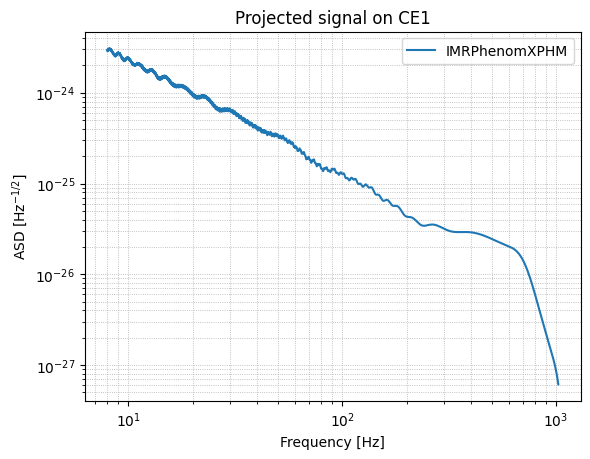

In [11]:
# Choose the detector onto which you want to project the signal
detector = 'CE1'
#detector = 'GW241011H'

# The following function outputs the signal projected onto the chosen detector
signal, _ = gw.utilities.get_fd_signal(parameters, detector, waveform_model, f_ref) # waveform_model and f_ref are passed together
frequency = gw.detection.Detector(detector).frequencyvector[:, 0]

# Plot the signal
plt.loglog(frequency, np.abs(signal[:, 0]), label='%s' %waveform_model)
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('ASD [Hz$^{-1/2}$]')
plt.grid(linestyle='dotted', linewidth='0.6', which='both')
plt.title('Projected signal on %s' %detector)
plt.show()

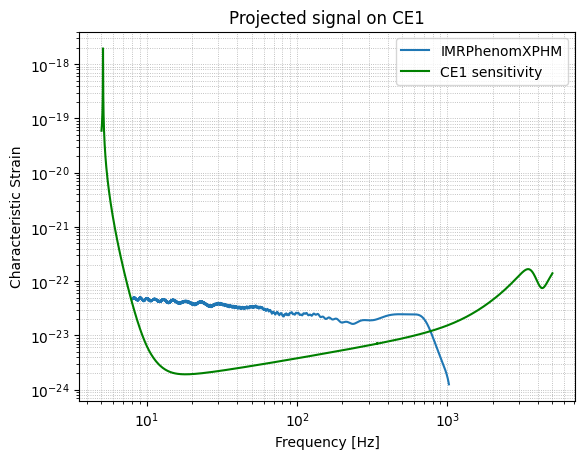

In [12]:
# add the detector's sensitivity curve and plot the characteristic strain
psd_data = gw.utilities.get_detector_psd(detector)
# psd_data is a dictionary with the keys 'frequency' and 'psd'

plt.loglog(frequency, 2 * frequency * np.abs(signal[:, 0]), label='%s' %waveform_model)
plt.loglog(psd_data[:, 0], np.sqrt(psd_data[:, 0] * psd_data[:, 1]), label='%s sensitivity' %detector, color='green')
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain')
plt.grid(linestyle='dotted', linewidth='0.6', which='both')
plt.title('Projected signal on %s' %detector)
plt.show()

In [13]:
# The networks are the combinations of detectors that will be used for the analysis
# The detection_SNR is the minimum SNR for a detection:
#   --> The first entry specifies the minimum SNR for a detection in a single detector
#   --> The second entry specifies the minimum network SNR for a detection
detectors = ['CE1', 'ET']
network = gw.detection.Network(detector_ids = detectors, detection_SNR = (0., 8.))
snr = gw.utilities.get_snr(parameters, network, waveform_model, f_ref)

In [14]:
snr

,CE1,ET,network
event_0,23.681096,42.658301,48.790623


In [15]:
# The fisher parameters are the parameters that will be used to calculate the Fisher matrix
# and on which we will calculate the errors
fisher_parameters = ['chirp_mass', 'mass_ratio', 'luminosity_distance','theta_jn', 'dec','ra',
                     'psi', 'phase', 'geocent_time', 'a_1', 'a_2', "tilt_1", "tilt_2", "phi_12", "phi_jl"]

In [16]:
detected, network_snr, parameter_errors, sky_localization = gw.fishermatrix.compute_network_errors(
        network = gw.detection.Network(detector_ids = ['CE1', 'ET'], detection_SNR = (0., 8.)),
        parameter_values = parameters,
        fisher_parameters=fisher_parameters, 
        waveform_model = waveform_model,
        f_ref = f_ref,
        use_duty_cycle = True
        )   
        # save_matrices = False, # default is False anyway, put True if you want Fisher and covariance matrices in the output
        # save_matrices_path = None, # default is None anyway,
                                     # otherwise specify the folder
                                     # where to save the Fisher and
                                     # corresponding covariance matrices

100%|██████████| 1/1 [00:06<00:00,  6.47s/it]


In [17]:
print('The network SNR of the event is ', network_snr)

The network SNR of the event is  [48.79062344]


In [18]:
print('The sky localization of the event is ', sky_localization)

The sky localization of the event is  [0.00028168]


In [19]:
# Choose percentile factor of sky localization and pass from rad2 to deg2
percentile = 90.
sky_localization_90cl = sky_localization * gw.fishermatrix.sky_localization_percentile_factor(percentile)
sky_localization_90cl

array([4.25842365])

In [20]:
# One can create a dictionary with the parameter errors, the order is the same as the one given in fisher_parameters
parameter_errors_dict = {}
for i, parameter in enumerate(fisher_parameters):
    parameter_errors_dict['err_' + parameter] = np.squeeze(parameter_errors)[i]

print('The parameter errors of the event are ')
parameter_errors_dict

The parameter errors of the event are 


{'err_chirp_mass': np.float64(0.0003661997085042818),
 'err_mass_ratio': np.float64(0.024963335094686255),
 'err_luminosity_distance': np.float64(328.2717670331831),
 'err_theta_jn': np.float64(0.08097982543985051),
 'err_dec': np.float64(0.018520741385377754),
 'err_ra': np.float64(0.016800502334081657),
 'err_psi': np.float64(0.11633140492708569),
 'err_phase': np.float64(0.2413680794609918),
 'err_geocent_time': np.float64(0.0003366152884268003),
 'err_a_1': np.float64(0.12610573325009425),
 'err_a_2': np.float64(0.16164258913461627),
 'err_tilt_1': np.float64(0.18506831994396794),
 'err_tilt_2': np.float64(0.18689006318759607),
 'err_phi_12': np.float64(0.000290890128209753),
 'err_phi_jl': np.float64(1.0352751323400309)}

In [21]:
# create folder to store results
!mkdir gwYYMMDD_results

mkdir: cannot create directory ‘gwYYMMDD_results’: File exists


In [22]:
data_folder = 'gwYYMMDD_results' # the one we just created
network = gw.detection.Network(detector_ids = ['CE1', 'ET'], detection_SNR = (0., 8.))
gw.fishermatrix.analyze_and_save_to_txt(network = network,
                                        parameter_values  = parameters,
                                        fisher_parameters = fisher_parameters, 
                                        sub_network_ids_list = [[0, 1]],  # both detectors
                                        population_name = 'BBH',
                                        waveform_model = waveform_model,
                                        f_ref = f_ref,
                                        save_path = data_folder,
                                        save_matrices = True)

100%|██████████| 1/1 [00:06<00:00,  6.46s/it]


In [23]:
# Load the matrices
fisher_matrix = np.load(data_folder + '/' + 'fisher_matrices_CE1_ET_BBH_SNR8.npy')
errors = pd.read_csv(data_folder + '/' + 'Errors_CE1_ET_BBH_SNR8.txt', delimiter = ' ')
cov_matrix = np.load(data_folder + '/' + 'inv_fisher_matrices_CE1_ET_BBH_SNR8.npy')[0, :, :]

In [24]:
# One can access all the column names of the errors output file:
errors

,network_SNR,chirp_mass,mass_ratio,luminosity_distance,theta_jn,ra,dec,psi,phase,geocent_time,...,err_psi,err_phase,err_geocent_time,err_a_1,err_a_2,err_tilt_1,err_tilt_2,err_phi_12,err_phi_jl,err_sky_location
0,48.790623,10.08,0.7848,4000.0,2.244,1.681,0.677,3.064,4.919,1.413000e+09,...,0.1163,0.2414,0.000337,0.1261,0.1616,0.1851,0.1869,0.000291,1.035,0.000282


In [25]:
# Save the mean values to sample
mean_lbs = ['chirp_mass', 'mass_ratio', 'luminosity_distance', 'theta_jn', 'dec', 'ra', 'psi',
            'phase', 'geocent_time', 'a_1', 'a_2', "tilt_1", "tilt_2", "phi_12", "phi_jl"]
mean_values = parameters[mean_lbs].iloc[0] # mean values of the parameters are just the parameters we injected

In [33]:
cov_matrix = 0.5 * (cov_matrix + cov_matrix.T)
cov_matrix += np.eye(cov_matrix.shape[0]) * 1e-10

In [34]:
np.random.seed(42) # fix for reproducibility
rng = np.random.default_rng()

#single_sample = np.random.multivariate_normal(mean_params, net.cov)
samples = np.random.multivariate_normal(mean_values, cov_matrix, int(1e3)) #<--- Lower
fisher_samples = pd.DataFrame(rng.multivariate_normal(mean_values, cov_matrix, int(1e6)), columns = fisher_parameters)

In [35]:
param_lbs = {'chirp_mass': r'$\mathcal{M}_c$ $[M_{\odot}]$', 'mass_ratio': r'$q$', 'luminosity_distance': r'$d_L$ [Mpc]',
                'dec': r'$\texttt{DEC}$ [rad]', 'ra': r'$\texttt{RA}$ [rad]', 'theta_jn': r'$\theta_{JN}$ [rad]', 'psi': r'$\Psi$ [rad]',
                'phase': r'$\phi$ [rad]', 'geocent_time': r'$t_c$ [rad][s]', 'a_1': r'$a_1$', 'a_2': r'$a_2$',
                'tilt_1': r'$\theta_1$ [rad]', 'tilt_2': r'$\theta_2$ [rad]', 'phi_12': r'$\phi_{12}$ [rad]',
                'phi_jl': r'$\phi_{JL}$ [rad]'}

In [36]:
samples = np.random.multivariate_normal(mean_values, cov_matrix, int(1e6))
samples_df = pd.DataFrame(samples, columns=fisher_parameters)

Below we have all the plots for the posterior distributions of the parameters.

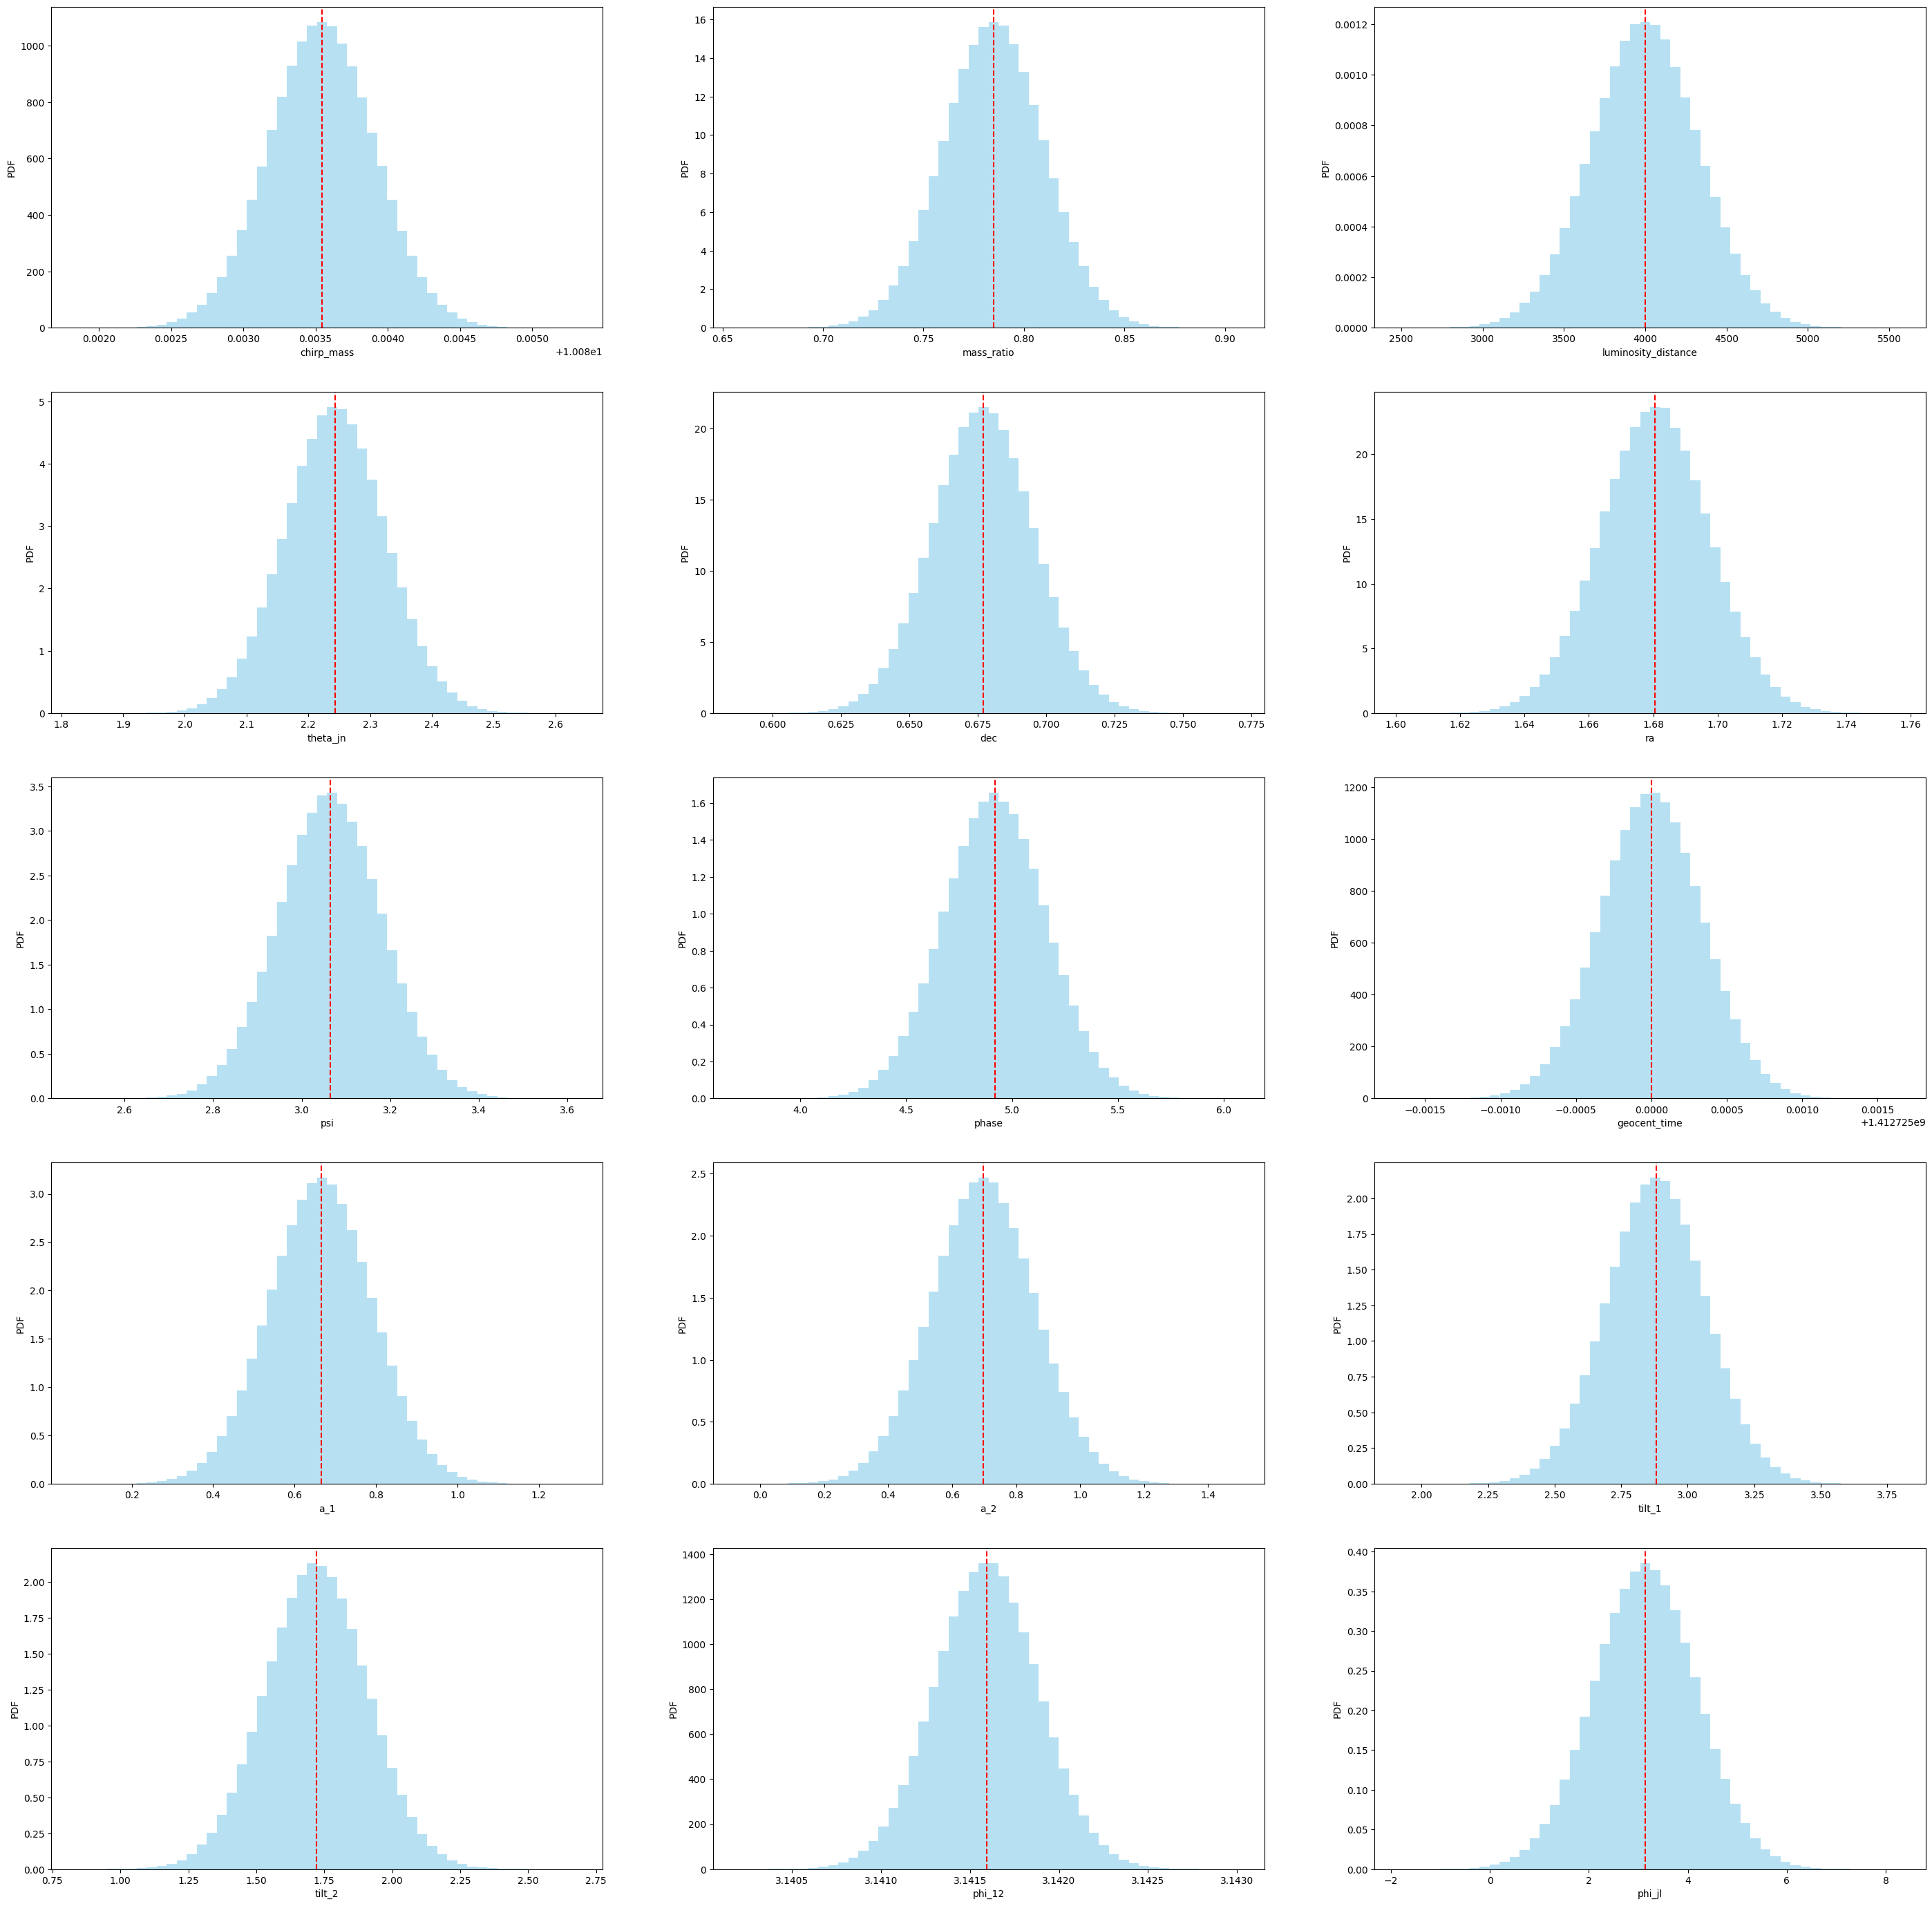

In [37]:
# Plot the posterior distribution of the parameter of choice
N = len(fisher_parameters)
fig = plt.figure(figsize=(35, 35))

for i in range(N):
    sel_param = fisher_parameters[i]
    injections = np.array(mean_values)
    plt.subplot(5, 3, i+1)  # 4 rows x 3 columns

    #No longer using truncated + priors, we are now only using the raw fisher analysis
    plt.hist(fisher_samples[fisher_parameters[i]], bins=50, density=True,
                label='Fisher', alpha = .6, color = 'skyblue') 
    
    #plt.hist(samples_from_truncated_lkh[fisher_parameters[i]], bins=50, histtype='step', density=True,
                #label='Fisher + Truncated', alpha = 1., color = 'blue')
    
    #plt.hist(samples_from_posterior[fisher_parameters[i]], bins=50, density=True,
                #label='Fisher + Truncated + Priors', alpha = .7, color = 'skyblue')
    #plt.axvline(injections[fisher_parameters.index(fisher_parameters[i])], color='black', linestyle='--', label='True Value')
    
    plt.axvline(mean_values[fisher_parameters[i]], color='red', linestyle='--', label='True Value')
    plt.xlabel(sel_param)  
    plt.ylabel('PDF')
#fig.legend(loc='center', bbox_to_anchor=(0.5, 0.95), ncol=2, frameon=False)

#plt.savefig("branches/Fisher_Samples_Priors.pdf")
plt.show()

Below we have all posterior distributions of the parameters that are not dependent on sky location and are important in the genealogy process.

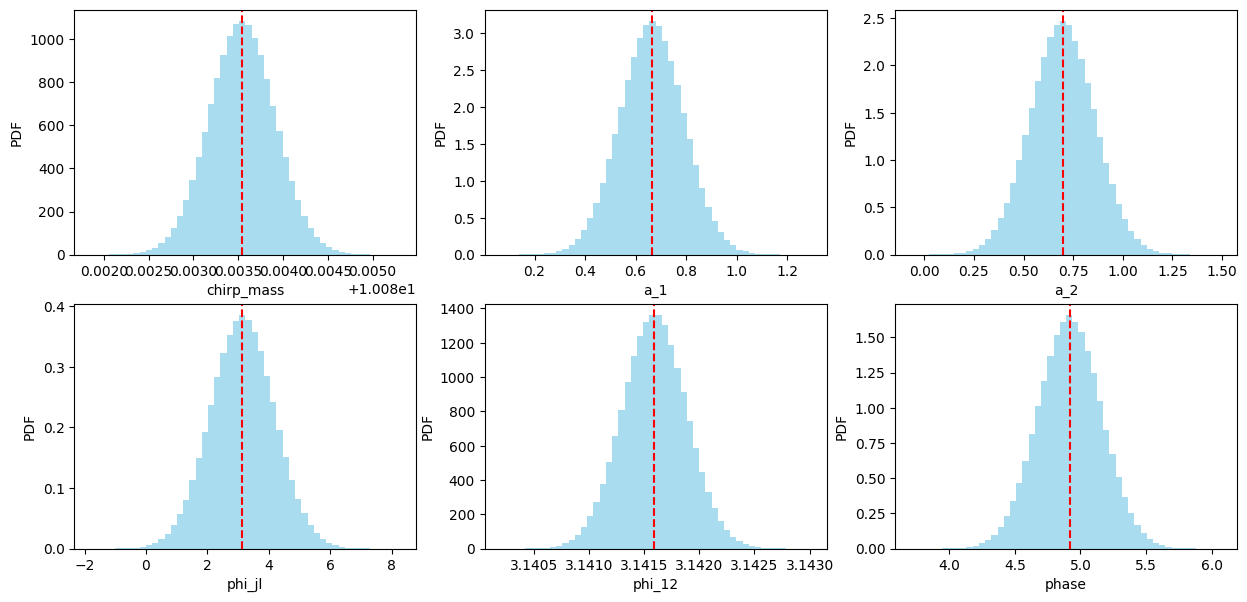

In [38]:
plot_params = ['chirp_mass', 'a_1', 'a_2', 'phi_jl', 'phi_12', 'phase']
N = len(plot_params)
fig = plt.figure(figsize=(15, 7))
for i in range(N):
    sel_param = plot_params[i]
    plt.subplot(2, 3, i+1)
    plt.hist(fisher_samples[sel_param], bins=50, density=True,
                label='Fisher + Truncated + Priors', alpha=.7, color='skyblue')
    plt.axvline(mean_values[sel_param], color='red', linestyle='--', label='True Value')
    plt.xlabel(sel_param)
    plt.ylabel('PDF')
    
plt.show()

In [39]:
fisher_samples.to_csv('data_csv/posteriors/test_fisher_posteriors.csv', index=False)

## Stage III — Genealogy Reconstruction

In [40]:
# Load the Fisher posteriors
fisher_posteriors = pd.read_csv('data_csv/posteriors/test_fisher_posteriors.csv')

In [41]:
def chirp_mass_and_q_to_m1(chirp_mass, mass_ratio):
    return chirp_mass * (1 + mass_ratio)**(1/5) / mass_ratio**(3/5)

def chirp_mass_and_q_to_m2(chirp_mass, mass_ratio):
    return chirp_mass_and_q_to_m1(chirp_mass, mass_ratio) * mass_ratio

# Load fisher posteriors
fisher_posteriors = pd.read_csv('data_csv/posteriors/test_fisher_posteriors.csv')
fisher_posteriors = bilby.gw.conversion.generate_mass_parameters(fisher_posteriors)

# Determine which mass to reconstruct based on remnant_role of current merger
role = df_merger.iloc[index]['remnant_role']

posteriors_candidate = pd.DataFrame()
if role == 'm1':
    posteriors_candidate["mass_source"] = chirp_mass_and_q_to_m1(
        fisher_posteriors["chirp_mass"],
        fisher_posteriors["mass_ratio"]
    )
    posteriors_candidate["spin"] = fisher_posteriors["a_1"]
elif role == 'm2':
    posteriors_candidate["mass_source"] = chirp_mass_and_q_to_m2(
        fisher_posteriors["chirp_mass"],
        fisher_posteriors["mass_ratio"]
    )
    posteriors_candidate["spin"] = fisher_posteriors["a_2"]
else:  # 'none' or 'unknown' — first merger or unmatched
    print(f"Warning: remnant_role is '{role}' for index {index}. Defaulting to m2.")
    posteriors_candidate["mass_source"] = chirp_mass_and_q_to_m2(
        fisher_posteriors["chirp_mass"],
        fisher_posteriors["mass_ratio"]
    )
    posteriors_candidate["spin"] = fisher_posteriors["a_2"]

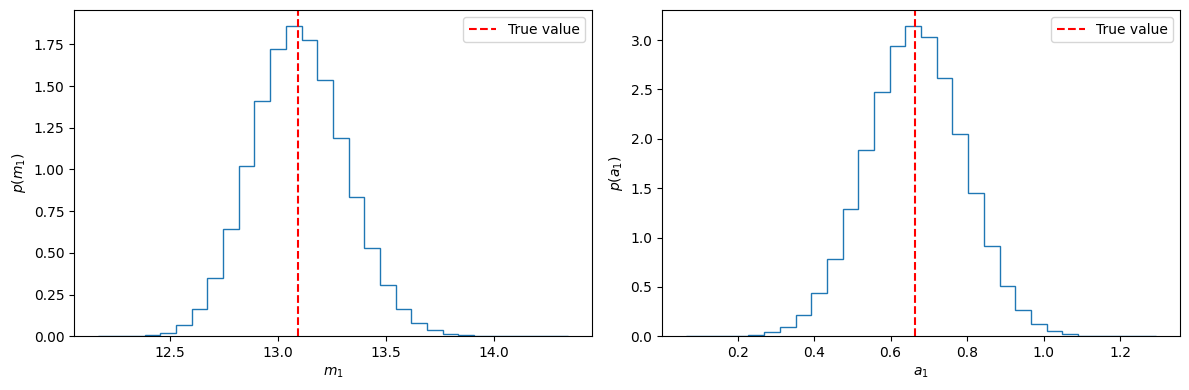

In [42]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

if role == 'm1':
    mass_true = true_values["m1"]
    spin_true = true_values["a1"]
    mass_label = r"$m_1$"
    spin_label = r"$a_1$"
    spin_col = fisher_posteriors["a_1"]
else:
    mass_true = true_values["m2"]
    spin_true = true_values["a2"]
    mass_label = r"$m_2$"
    spin_label = r"$a_2$"
    spin_col = fisher_posteriors["a_2"]

ax[0].hist(posteriors_candidate["mass_source"], histtype="step", bins=30, density=True)
ax[0].axvline(mass_true, color='red', linestyle='--', label='True value')
ax[0].set_xlabel(mass_label)
ax[0].set_ylabel(rf"$p({mass_label[1:-1]})$")
ax[0].legend()

ax[1].hist(spin_col, histtype="step", bins=30, density=True)
ax[1].axvline(spin_true, color='red', linestyle='--', label='True value')
ax[1].set_xlabel(spin_label)
ax[1].set_ylabel(rf"$p({spin_label[1:-1]})$")
ax[1].legend()

plt.tight_layout()
plt.show()

In [43]:
# Define the parameters to sample for and that functions will take in
parameter_names = ['mass_1_source', 'mass_2_source', 'a_1', 'a_2', 'cos_tilt_1', 'cos_tilt_2', 'phi_12']

In [44]:
# Define some useful conversion functions
# Effective spin
def chi_eff(mass_1_source, mass_2_source, a_1, a_2, cos_tilt_1, cos_tilt_2, phi_12):
    """
    Calculate the effective spin parameter (chi_eff).

    Parameters:
        mass_1_source (float): Source mass of the primary black hole.
        mass_2_source (float): Source mass of the secondary black hole.
        a_1 (float): Dimensionless spin magnitude of the primary.
        a_2 (float): Dimensionless spin magnitude of the secondary.
        cos_tilt_1 (float): Cosine of the tilt angle for the primary spin.
        cos_tilt_2 (float): Cosine of the tilt angle for the secondary spin.
        phi_12 (float): Difference in azimuthal angles between the two spins.

    Returns:
        float: Effective spin parameter (chieff).
    """
    q = mass_2_source / mass_1_source

    # Effective spin parameter
    chieff = (a_1 * cos_tilt_1 + q * a_2 * cos_tilt_2) / (1. + q)

    return chieff

# Effective precession parameters
def chi_p(mass_1_source, mass_2_source, a_1, a_2, cos_tilt_1, cos_tilt_2, phi_12):
    """
    Calculate the effective precession parameter (chi_p).

    Parameters:
        mass_1_source (float): Source mass of the primary black hole.
        mass_2_source (float): Source mass of the secondary black hole.
        a_1 (float): Dimensionless spin magnitude of the primary.
        a_2 (float): Dimensionless spin magnitude of the secondary.
        cos_tilt_1 (float): Cosine of the tilt angle for the primary spin.
        cos_tilt_2 (float): Cosine of the tilt angle for the secondary spin.
        phi_12 (float): Difference in azimuthal angles between the two spins.

    Returns:
        float: Effective precession parameter (chi_p).
    """
    q = mass_2_source / mass_1_source

    # Calculate sin(tilt) using cos(tilt)
    sintilt1 = np.sqrt(1 - cos_tilt_1**2)
    sintilt2 = np.sqrt(1 - cos_tilt_2**2)

    # Effective precession parameter
    chi_p = np.maximum(a_1 * sintilt1,
                (q * (4. * q + 3.) / (4. + 3. * q)) * a_2 * sintilt2)

    return chi_p


def convert_m1_m2_to_q(parameters):
    """
    Function to convert between sampled parameters and constraint parameter.

    Parameters
    ----------
    parameters: dict
        Dictionary containing sampled parameter values, 'mass_1_source', 'mass_2_source'.

    Returns
    -------
    dict: Dictionary with constraint parameter 'mass_ratio' added.
    """
    converted_parameters = parameters.copy()
    converted_parameters['mass_ratio'] = parameters['mass_2_source']/parameters['mass_1_source']
    return converted_parameters

In [45]:
# Derive component masses
fisher_posteriors["mass_1_source"] = chirp_mass_and_q_to_m1(
    fisher_posteriors["chirp_mass"],
    fisher_posteriors["mass_ratio"]
)
fisher_posteriors["mass_2_source"] = fisher_posteriors["mass_1_source"] * fisher_posteriors["mass_ratio"]

# Derive cos_tilt
fisher_posteriors["cos_tilt_1"] = np.cos(fisher_posteriors["tilt_1"])
fisher_posteriors["cos_tilt_2"] = np.cos(fisher_posteriors["tilt_2"])

In [46]:
# Define the NR fits that will be used to obtain the final mass and spin
def remnant_mass(mass_1_source, mass_2_source, a_1, a_2, cos_tilt_1, cos_tilt_2, phi_12):
    M = mass_1_source + mass_2_source
    q = mass_2_source / mass_1_source
    return precession.remnantmass(
        np.arccos(cos_tilt_1),
        np.arccos(cos_tilt_2),
        q,
        a_1,
        a_2,
    ) * M

def remnant_spin(mass_1_source, mass_2_source, a_1, a_2, cos_tilt_1, cos_tilt_2, phi_12):
    M = mass_1_source + mass_2_source
    q = mass_2_source / mass_1_source
    return precession.remnantspin(
        np.arccos(cos_tilt_1),
        np.arccos(cos_tilt_2),
        phi_12,
        q,
        a_1,
        a_2,
    )

def remnant_kick(mass_1_source, mass_2_source, a_1, a_2, cos_tilt_1, cos_tilt_2, phi_12):
    M = mass_1_source + mass_2_source
    q = mass_2_source / mass_1_source
    return precession.remnantkick(
        np.arccos(cos_tilt_1),
        np.arccos(cos_tilt_2),
        phi_12,
        q,
        a_1,
        a_2,
        kms = True,
    )

In [47]:
#Priors on parent parameters
#mass_1_source, mass_2_source, a_1, a_2, cos_tilt_1, cos_tilt_2, phi_12
priors = bilby.core.prior.PriorDict(conversion_function=convert_m1_m2_to_q)
#priors["mass_1_source"] = bilby.core.prior.Uniform(minimum=5, maximum=300, latex_label=r'$m_{\mathrm{1, p}}$')
#priors["mass_2_source"] = bilby.core.prior.Uniform(minimum=5, maximum=300, latex_label=r'$m_{\mathrm{2, p}}$')
priors["mass_1_source"] = bilby.core.prior.Uniform(minimum=5, maximum=100)
priors["mass_2_source"] = bilby.core.prior.Uniform(minimum=5, maximum=100)
priors["mass_ratio"] = bilby.core.prior.Constraint(minimum=1/6, maximum=.99)

priors["a_1"] = bilby.core.prior.Uniform(minimum=0.0, maximum=0.99, latex_label=r'$\chi_{\mathrm{1, p}}$')
priors["a_2"] = bilby.core.prior.Uniform(minimum=0.0, maximum=0.99, name="a_2", latex_label=r'$\chi_{\mathrm{2, p}}$')

priors["cos_tilt_1"] = bilby.core.prior.Uniform(minimum=-1, maximum=1, latex_label=r'$\mathrm{cos \theta_{\mathrm{1, p}}}$')
priors["cos_tilt_2"] = bilby.core.prior.Uniform(minimum=-1, maximum=1, latex_label=r'$\mathrm{cos \theta_{\mathrm{2, p}}}$')
priors["phi_12"] = bilby.core.prior.Uniform(minimum=0, maximum=2*np.pi, boundary='periodic', latex_label=r'$\phi_{\mathrm{12, p}}$')

In [48]:
# Subsample to 5000 points
posteriors_candidate_sub = posteriors_candidate.sample(n=5000, random_state=42).reset_index(drop=True)

genealogy = ancestral.Genealogy_Reconstruction(
    posteriors_candidate=posteriors_candidate_sub,  # use subsampled version
    parameter_names=parameter_names,
    label='tutorial',
    outdir='tutorial',
    Mfin_NRfit=remnant_mass,
    Chifin_NRfit=remnant_spin,
    Vkick_NRfit=remnant_kick,
    Chieff=chi_eff,
    chip=chi_p,
    priors=priors,
    method='gmm',
    method_kwargs={
        'n_components': 5,
        'covariance_type': 'full',
        'max_iter': 1000,
        'tol': 0.001,
        'random_state': 42
    },
    interp_method='interp2d',
    sampler_kwargs=dict(
        nlive=2000, naccept=20, sample='acceptance-walk', save='hdf5',
    ),
)

In [61]:
#ONLY RUN THIS IF YOU WISH TO START THE GENEALOGY RECONSTRUCTION FROM SCRATCH

for f in ["tutorial/tutorial_resume.pickle"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted {f}")

Deleted tutorial/tutorial_resume.pickle


In [62]:
genealogy.run_analysis() 

13:28 bilby INFO    : Running for label 'tutorial', output will be saved to 'tutorial'


Start
Sampling started for estimating the parameters of parent binary


13:28 bilby INFO    : Analysis priors:
13:28 bilby INFO    : mass_1_source=Uniform(minimum=5, maximum=100, name=None, latex_label=None, unit=None, boundary=None)
13:28 bilby INFO    : mass_2_source=Uniform(minimum=5, maximum=100, name=None, latex_label=None, unit=None, boundary=None)
13:28 bilby INFO    : a_1=Uniform(minimum=0.0, maximum=0.99, name=None, latex_label='$\\chi_{\\mathrm{1, p}}$', unit=None, boundary=None)
13:28 bilby INFO    : a_2=Uniform(minimum=0.0, maximum=0.99, name='a_2', latex_label='$\\chi_{\\mathrm{2, p}}$', unit=None, boundary=None)
13:28 bilby INFO    : cos_tilt_1=Uniform(minimum=-1, maximum=1, name=None, latex_label='$\\mathrm{cos \\theta_{\\mathrm{1, p}}}$', unit=None, boundary=None)
13:28 bilby INFO    : cos_tilt_2=Uniform(minimum=-1, maximum=1, name=None, latex_label='$\\mathrm{cos \\theta_{\\mathrm{2, p}}}$', unit=None, boundary=None)
13:28 bilby INFO    : phi_12=Uniform(minimum=0, maximum=6.283185307179586, name=None, latex_label='$\\phi_{\\mathrm{12, p}}$

592it [10:38,  1.03s/it, bound:1076 nc:833 ncall:1.1e+06 eff:0.1% logz=-691.99+/-0.03 dlogz:695>0.1] 

13:39 bilby INFO    : Written checkpoint file tutorial/tutorial_resume.pickle


...

13958it [35:35,  6.54it/s, bound:3762 nc:  1 ncall:3.5e+06 eff:0.5% logz=-6.74+/-0.07 dlogz:4.78e-05>0.1]

14:04 bilby INFO    : Rejection sampling nested samples to obtain 4390 posterior samples
14:04 bilby INFO    : Sampling time: 0:35:35.291515
14:04 bilby INFO    : Summary of results:
nsamples: 4390
ln_noise_evidence:    nan
ln_evidence: -6.745 +/-  0.087
ln_bayes_factor:    nan +/-  0.087





Sampling ended


14:04 bilby INFO    : Plotting mass_1_source marginal distribution
14:04 bilby INFO    : Plotting mass_1_source marginal distribution
14:04 bilby INFO    : Plotting mass_2_source marginal distribution
14:04 bilby INFO    : Plotting mass_2_source marginal distribution
14:04 bilby INFO    : Plotting a_1 marginal distribution
14:04 bilby INFO    : Plotting a_1 marginal distribution
14:04 bilby INFO    : Plotting a_2 marginal distribution
14:04 bilby INFO    : Plotting a_2 marginal distribution
14:04 bilby INFO    : Plotting cos_tilt_1 marginal distribution
14:04 bilby INFO    : Plotting cos_tilt_1 marginal distribution
14:04 bilby INFO    : Plotting cos_tilt_2 marginal distribution
14:04 bilby INFO    : Plotting cos_tilt_2 marginal distribution
14:04 bilby INFO    : Plotting phi_12 marginal distribution
14:04 bilby INFO    : Plotting phi_12 marginal distribution
14:04 bilby INFO    : Plotting log_likelihood marginal distribution
14:04 bilby INFO    : Plotting log_likelihood marginal distr

Started Chieff/Chip/Vkick/Mfinal/Chifinal calculation
Finished Chieff/Chip/Vkick/Mfinal/Chifinal calculation
End


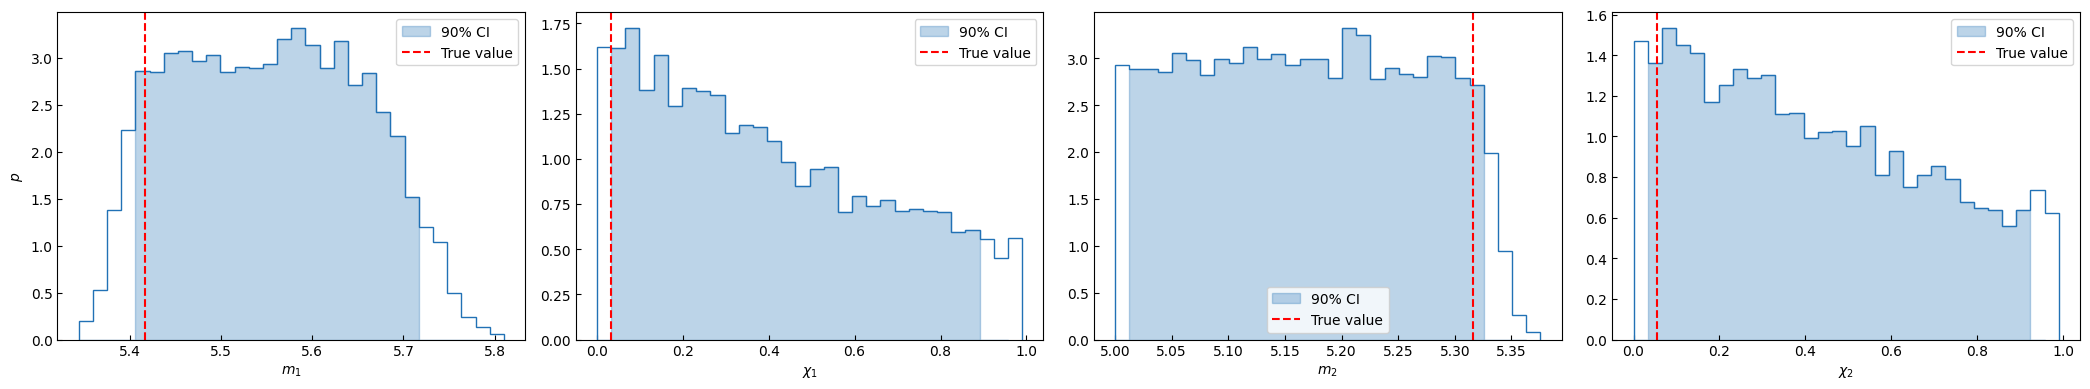

In [66]:
fig, ax = plt.subplots(1, 4, figsize=(21, 4))

current_row = df_merger.iloc[index -1]
true_vals = [current_row["mass_1"], current_row["a_1"], current_row["mass_2"], current_row["a_2"]]
samples_list = [m1, a1, m2, a2]
labels       = [r"$m_1$", r"$\chi_1$", r"$m_2$", r"$\chi_2$"]

for i, (samples, label, true_val) in enumerate(zip(samples_list, labels, true_vals)):
    lo, hi = np.percentile(samples, [5, 95])
    
    # Compute histogram
    counts, bin_edges = np.histogram(samples, bins=30, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Plot full histogram
    ax[i].hist(samples, bins=30, histtype="step", density=True, color="#2171b5")
    
    # Shade only the bins within the 90% CI
    mask = (bin_centers >= lo) & (bin_centers <= hi)
    ax[i].fill_between(bin_edges[:-1], 0, 
                        np.where(mask, counts, 0),
                        step='post', alpha=0.3, color="#2171b5", label='90% CI')
    
    ax[i].axvline(true_val, color='red', linestyle='--', label='True value')
    ax[i].set_xlabel(label)
    ax[i].tick_params(direction='in', which='both')
    ax[i].legend()

ax[0].set_ylabel(r"$p$")
plt.tight_layout()
plt.savefig("posteriors.png", bbox_inches="tight", dpi=150)
plt.show()

## Stage IV — Accuracy & Likelihood Analysis

In [67]:
import h5py
import numpy as np

with h5py.File("tutorial/tutorial_result.hdf5", "r") as f:
    m1     = f["posterior"]["mass_1_source"][:]
    m2     = f["posterior"]["mass_2_source"][:]
    a1     = f["posterior"]["a_1"][:]
    a2     = f["posterior"]["a_2"][:]
    chieff = f["posterior"]["chi_eff"][:]
    vkick  = f["posterior"]["final_kick"][:]
    mfin   = f["posterior"]["final_mass_source"][:]
    chifin = f["posterior"]["final_spin"][:]
    logl   = f["posterior"]["log_likelihood"][:]

# Find the maximum likelihood index
maxL_idx = np.argmax(logl)

print(f"m1     = {m1[maxL_idx]:.1f}")
print(f"m2     = {m2[maxL_idx]:.1f}")
print(f"a1     = {a1[maxL_idx]:.2f}")
print(f"a2     = {a2[maxL_idx]:.2f}")
print(f"chieff = {chieff[maxL_idx]:.2f}")
print(f"vkick  = {vkick[maxL_idx]:.0f}")
print(f"mfin   = {mfin[maxL_idx]:.1f}")
print(f"chifin = {chifin[maxL_idx]:.2f}")

m1     = 5.7
m2     = 5.0
a1     = 0.55
a2     = 0.33
chieff = -0.05
vkick  = 1057
mfin   = 10.2
chifin = 0.69


In [68]:
true_vals

[np.float64(5.4165644407073925),
 np.float64(0.0327746035887921),
 np.float64(5.316007513881405),
 np.float64(0.0541277660121925)]

In [91]:
import os
import json

branch_id = 1
log_path = f"/home/santiago.berumen/branches/data_csv/reconstruction_database.csv"
true_parent_values = {
    "m1":    df_merger.iloc[index - 1]['mass_1'],
    "m2":    df_merger.iloc[index - 1]['mass_2'],
    "a1":    df_merger.iloc[index - 1]['a_1'],
    "a2":    df_merger.iloc[index - 1]['a_2'],
    "m_rem": df_merger.iloc[index - 1]['m_f'],
    "a_rem": df_merger.iloc[index - 1]['a_f'],
    "vkick": df_merger.iloc[index - 1]['v_k'],
}

def log_run(seed, index, branch_id, true_parent_values, maxL_results, chi_eff,
            m1_samples, m2_samples, a1_samples, a2_samples,
            log_evidence, log_bf, log_path=log_path):
    new_entry = {
        "seed":         seed,
        "branch_id":    branch_id,
        "merger_index": index,
        "true_m1":      true_parent_values["m1"],
        "true_m2":      true_parent_values["m2"],
        "true_a1":      true_parent_values["a1"],
        "true_a2":      true_parent_values["a2"],
        "true_m_rem":   true_parent_values["m_rem"],
        "true_a_rem":   true_parent_values["a_rem"],
        "true_vkick":   true_parent_values["vkick"],
        "rec_m1":       maxL_results["m1"],
        "rec_m2":       maxL_results["m2"],
        "rec_a1":       maxL_results["a1"],
        "rec_a2":       maxL_results["a2"],
        "rec_mfin":     maxL_results["mfin"],
        "rec_chifin":   maxL_results["chifin"],
        "rec_vkick":    maxL_results["vkick"],
        "ci_m1_low":    float(np.percentile(m1_samples, 5)),
        "ci_m1_high":   float(np.percentile(m1_samples, 95)),
        "ci_m2_low":    float(np.percentile(m2_samples, 5)),
        "ci_m2_high":   float(np.percentile(m2_samples, 95)),
        "ci_a1_low":    float(np.percentile(a1_samples, 5)),
        "ci_a1_high":   float(np.percentile(a1_samples, 95)),
        "ci_a2_low":    float(np.percentile(a2_samples, 5)),
        "ci_a2_high":   float(np.percentile(a2_samples, 95)),
        "chi_eff":      chi_eff,
        "log_evidence": log_evidence,
        "log_bf":       log_bf,
    }

    if os.path.exists(log_path):
        df_log = pd.read_csv(log_path)
    else:
        df_log = pd.DataFrame()

    if not df_log.empty:
        match = (
            (df_log["seed"] == seed) &
            (df_log["merger_index"] == index) &
            (df_log["branch_id"] == branch_id)
        )
        if match.any():
            response = input(f"Seed {seed}, branch {branch_id}, index {index} already logged. Replace? (y/n): ")
            if response.strip().lower() == 'y':
                df_log = df_log[~match]
                print("Replaced existing entry.")
            else:
                print("Keeping existing entry, run not logged.")
                return df_log

    df_log = pd.concat([df_log, pd.DataFrame([new_entry])], ignore_index=True)
    df_log.to_csv(log_path, index=False)
    print(f"Run logged to {log_path}")
    return df_log

# --- Load result and build maxL ---
result = bilby.core.result.read_in_result("tutorial/tutorial_result.hdf5")

maxL_results = {
    "m1":     m1[maxL_idx],
    "m2":     m2[maxL_idx],
    "a1":     a1[maxL_idx],
    "a2":     a2[maxL_idx],
    "mfin":   mfin[maxL_idx],
    "chifin": chifin[maxL_idx],
    "vkick":  vkick[maxL_idx],
}

df_log = log_run(
    seed=seed,
    index=index,
    branch_id=branch_id,
    true_parent_values=true_parent_values,
    maxL_results=maxL_results,
    chi_eff=float(chieff[maxL_idx]),
    m1_samples=m1,
    m2_samples=m2,
    a1_samples=a1,
    a2_samples=a2,
    log_evidence=result.log_evidence,
    log_bf=result.log_bayes_factor
)

display(df_log.style.format(precision=3))

Seed 22, branch 1, index 1 already logged. Replace? (y/n):  y


Replaced existing entry.
Run logged to /home/santiago.berumen/branches/data_csv/reconstruction_database.csv


,seed,branch_id,merger_index,true_m1,true_m2,true_a1,true_a2,true_m_rem,true_a_rem,true_vkick,rec_m1,rec_m2,rec_a1,rec_a2,rec_mfin,rec_chifin,rec_vkick,chi_eff,ci_m1_low,ci_m1_high,ci_m2_low,ci_m2_high,ci_a1_low,ci_a1_high,ci_a2_low,ci_a2_high,log_evidence,log_bf
0,14,1,2,14.969,12.515,0.680,0.657,41.384,0.721,1306.121,18.282,8.909,0.760,0.255,25.510,0.853,591.318,0.470,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,4,1,2,27.066,13.813,0.604,0.691,100.821,0.758,363.256,29.166,11.694,0.490,0.811,39.770,0.419,315.328,-0.233,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,25,1,2,19.504,12.369,0.584,0.677,58.766,0.597,1430.696,20.513,11.312,0.637,0.316,30.098,0.781,793.168,0.265,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
3,1,1,2,34.204,11.533,0.374,0.669,44.217,0.639,453.931,27.915,18.308,0.473,0.451,44.268,0.641,501.315,-0.008,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
4,80,1,2,15.194,14.336,0.660,0.657,35.711,0.730,1484.829,19.945,9.500,0.057,0.808,28.372,0.596,402.603,-0.103,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
5,60,1,2,39.430,13.349,0.376,0.642,51.275,0.535,680.403,29.885,23.340,0.770,0.700,51.362,0.531,1243.600,-0.445,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
6,64,1,2,66.889,13.884,0.653,0.664,79.491,0.505,1220.702,53.390,28.738,0.953,0.804,79.590,0.506,799.509,-0.247,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
7,10,1,2,79.491,31.689,0.505,0.598,106.800,0.685,1220.702,62.136,19.639,0.137,0.580,79.572,0.505,214.636,-0.080,48.608,68.178,12.894,33.661,0.039,0.913,0.055,0.934,-4.518,nan
8,28,1,2,61.843,47.085,0.607,0.748,104.916,0.552,646.910,48.172,15.794,0.187,0.193,61.852,0.607,195.601,0.123,33.746,52.104,11.061,30.584,0.039,0.890,0.050,0.940,-4.460,nan
9,30,1,2,39.901,32.395,0.447,0.629,68.443,0.746,413.991,32.638,31.642,0.968,0.865,61.857,0.607,619.286,-0.375,33.795,52.063,11.161,30.564,0.035,0.891,0.052,0.938,-4.460,nan


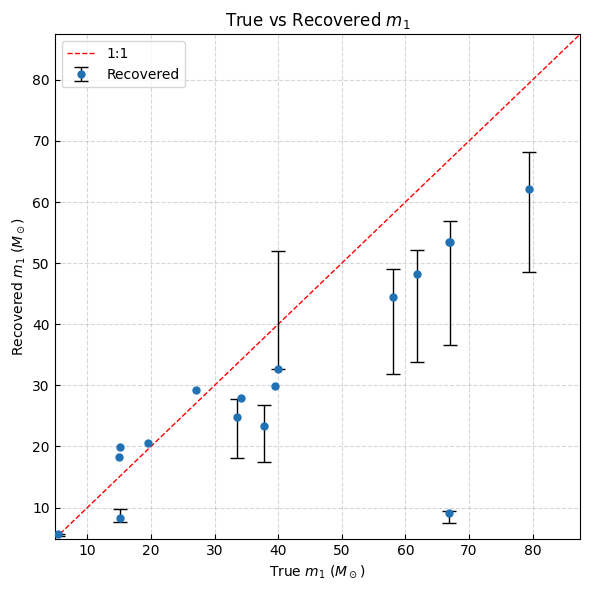

In [92]:
df_log = pd.read_csv(log_path)

fig, ax = plt.subplots(figsize=(6, 6))

yerr_low  = (df_log["rec_m1"] - df_log["ci_m1_low"]).clip(lower=0)
yerr_high = (df_log["ci_m1_high"] - df_log["rec_m1"]).clip(lower=0)

ax.errorbar(
    df_log["true_m1"], df_log["rec_m1"],
    yerr=[yerr_low, yerr_high],
    fmt='o', color="#2171b5", ecolor="black",
    elinewidth=1, capsize=5, capthick=1,
    ms=5, zorder=3, label='Recovered'
)

# 1:1 line
lims = [
    min(df_log["true_m1"].min(), df_log["rec_m1"].min()) * 0.9,
    max(df_log["true_m1"].max(), df_log["rec_m1"].max()) * 1.1
]
ax.plot(lims, lims, 'r--', lw=1, label='1:1')

ax.set_ylabel(r"Recovered $m_1$ $(M_\odot)$")
ax.set_xlabel(r"True $m_1$ $(M_\odot)$")
ax.set_ylim(lims)
ax.set_xlim(lims)
ax.set_title(r"True vs Recovered $m_1$")
ax.tick_params(direction='in', which='both')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("true_vs_recovered_m1.png", bbox_inches="tight", dpi=150)
plt.show()